**Imports**

This section imports the libraries required for the project. These libraries provide functionality for image processing, deep learning model building, evaluation, and visualization.

os – used to navigate folders and file paths for the dataset.

torch – the core deep learning framework used to build and train neural networks.

numpy – provides numerical operations for handling arrays and tensors.

matplotlib and seaborn – used for data visualization, such as plotting the confusion matrix and model performance.

PIL (Python Imaging Library) – used to load and manipulate image files.

torchvision – provides prebuilt computer vision models and image transformation tools.

torch.nn – contains neural network layers and loss functions.

torch.optim – provides optimization algorithms used during training.

sklearn.metrics – used to generate evaluation metrics such as classification reports and confusion matrices.

In [29]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from PIL import Image

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import classification_report, confusion_matrix

**Dataset Paths**

This section defines the file paths to the dataset directories. The dataset is organized into three subsets:

Training set – used to train the model.

Validation set – used to tune hyperparameters and evaluate model performance during development.

Test set – used for final evaluation after the model is fully trained.

Each dataset contains two folders:

images – the image files

labels – YOLO format label files containing the class index

In [30]:
dataset_path = "Final_Dataset"

train_img = os.path.join(dataset_path, "Train/images")
train_lbl = os.path.join(dataset_path, "Train/labels")

val_img = os.path.join(dataset_path, "Validation/images")
val_lbl = os.path.join(dataset_path, "Validation/labels")

test_img = os.path.join(dataset_path, "Test/images")
test_lbl = os.path.join(dataset_path, "Test/labels")

**Bird Species Classes**

This section defines the list of bird species that the model will classify. Each class corresponds to a specific bird species represented in the dataset.

The variable num_classes calculates the total number of species in the dataset, which determines the number of output neurons in the final layer of the neural network.

Rationale

Deep learning classification models require the number of output classes to match the number of categories in the dataset. Explicitly defining the class list also allows meaningful labels to be displayed in the classification report.

In [31]:
classes = [
"Agelaius_phoeniceus",
"Ammodramus_savannarum",
"Anthus_spinoletta",
"Cardellina_pusilla",
"Certhia_americana",
"Cistothorus_palustris",
"Euphagus_cyanocephalus",
"Geothlypis_tolmiei",
"Geothlypis_trichas",
"Icteria_virens",
"Junco_hyemalis",
"Molothrus_ater",
"Passer_domesticus",
"Passerella_iliaca",
"Poecile_atricapillus",
"Pooecetes_gramineus",
"Quiscalus_quiscula",
"Setophaga_petechia",
"Setophaga_ruticilla",
"Vireo_olivaceus",
"Zonotrichia_albicollis"
]

num_classes = len(classes)

**Image Transformation**

This section defines preprocessing transformations applied to all images before they are fed into the neural network.

The transformations include:

Resize((224,224)) – resizes images to a fixed size.

ToTensor() – converts images into PyTorch tensors.

Normalize() – scales pixel values using ImageNet normalization parameters.

Neural networks require images to have the same dimensions. The size 224×224 is used because it is the standard input size for many pretrained CNN models such as ResNet and MobileNet.

Additionally, resizing the images helped reduce the computational cost of training, since the original images were larger and would significantly increase training time and memory usage.

In [32]:
transform = transforms.Compose([
    transforms.Resize((224,224)),   # forces all images to same size
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

**YOLO Dataset Loader**

The dataset is stored in YOLO format, where labels are saved as text files containing object annotations. However, for this classification task only the class ID is needed.

Creating a custom dataset class allows PyTorch’s DataLoader to efficiently load and batch images during training.

In [33]:

class YOLOEggDataset(Dataset):

    def __init__(self, image_dir, label_dir, transform=None):

        self.image_dir = image_dir
        self.label_dir = label_dir
        self.transform = transform

        valid_ext = (".jpg", ".jpeg", ".png")

        self.images = [f for f in os.listdir(image_dir)
                       if f.lower().endswith(valid_ext)]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):

        img_name = self.images[index]

        img_path = os.path.join(self.image_dir, img_name)
        

        base_name = os.path.splitext(img_name)[0]

        # Remove prefix if it exists
        if "-" in base_name:
            core_name = base_name.split("-", 1)[1]
        else:
            core_name = base_name

        label_path = None

        # Try exact match first
        exact_label = os.path.join(self.label_dir, base_name + ".txt")
        if os.path.exists(exact_label):
            label_path = exact_label
        else:
            # Match using species name + number
            for lbl in os.listdir(self.label_dir):
                lbl_base = os.path.splitext(lbl)[0]

                if "-" in lbl_base:
                    lbl_core = lbl_base.split("-", 1)[1]
                else:
                    lbl_core = lbl_base

                if lbl_core == core_name:
                    label_path = os.path.join(self.label_dir, lbl)
                    break

        # Safety fallback
        if label_path is None:
            return self.__getitem__((index + 1) % len(self.images))

        
        image = Image.open(img_path).convert("RGB")

        with open(label_path) as f:
            label = int(float(f.readline().split()[0]))

        if self.transform:
            image = self.transform(image)

        return image, label

**Load Datasets**

This section initializes the dataset objects for the training, validation, and test datasets using the custom dataset loader.

It also prints the number of samples in each dataset to verify that the data has been loaded correctly.

In [34]:
train_dataset = YOLOEggDataset(train_img, train_lbl, transform)
val_dataset = YOLOEggDataset(val_img, val_lbl, transform)
test_dataset = YOLOEggDataset(test_img, test_lbl, transform)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 2205
Validation: 315
Test: 630


**Data Loader**

This section creates DataLoader objects, which handle batching and efficient data loading during training and evaluation.

batch_size = 32 determines how many images are processed in one iteration.

shuffle = True randomizes the training data order to improve model generalization.

In [35]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader = DataLoader(val_dataset,batch_size=32)
test_loader = DataLoader(test_dataset,batch_size=32)

In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


**Model Function**

*ResNet18*

A residual convolutional neural network known for strong performance in image classification tasks.

Uses skip connections that allow deeper networks to train effectively.

Provides a good balance between accuracy and computational efficiency.

*MobileNetV2*

Designed for lightweight and efficient image classification.

Uses depthwise separable convolutions to reduce computational cost.

Suitable for environments with limited computational resources.

Testing both models allows comparison between a higher-capacity architecture (ResNet) and a lightweight architecture (MobileNet).

In [37]:
def get_model(name):

    if name == "resnet18":

        model = models.resnet18(pretrained=True)
        model.fc = nn.Linear(model.fc.in_features,num_classes)

    elif name == "mobilenet":

        model = models.mobilenet_v2(pretrained=True)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features,num_classes)

    return model.to(device)

**Training Function**

This function trains the neural network for a specified number of epochs.

The training process includes:

Forward propagation through the model

Calculating the loss using CrossEntropyLoss

Backpropagation to compute gradients

Updating model weights using the AdamW optimizer

The average training loss for each epoch is printed.

In [38]:
def train_model(model,epochs,lr):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.AdamW(model.parameters(),lr=lr)

    for epoch in range(epochs):

        model.train()

        running_loss = 0

        for images,labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs,labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} Loss: {running_loss/len(train_loader):.4f}")

    return model

**Validation Function**

The validation dataset allows evaluation of model performance during training and hyperparameter tuning without using the test set.

This prevents the test set from influencing model design.

In [39]:
def validate_model(model):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images,labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _,preds = torch.max(outputs,1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return correct/total

**Hyperparameter Tuning (Grid Search)**

The learning rates tested represent:

0.001 – a commonly used default learning rate

0.0003 – a smaller rate that can lead to more stable training

The number of epochs was limited to 3 because training deep neural networks on large image datasets can be computationally expensive in a notebook environment.

In [40]:
models_to_test = ["resnet18","mobilenet"]

learning_rates = [0.001,0.0003]
epoch_options = [3]

results = []

In [41]:
if os.path.exists("results.csv"):
    print("Loading previous results...")
    results_df = pd.read_csv("results.csv")

else:
    print("Running grid search...")
    results = []

    for model_name in models_to_test:
        for lr in learning_rates:
            for epochs in epoch_options:

                model_filename = f"{model_name}_lr{lr}_epochs{epochs}.pth"

                #Skip training if model already exists
                if os.path.exists(model_filename):
                    print(f"Loading saved model: {model_filename}")
                    model = get_model(model_name)
                    model.load_state_dict(torch.load(model_filename, map_location=device))
                    model.eval()

                else:
                    print("\nTraining:", model_name, "LR:", lr, "Epochs:", epochs)

                    model = get_model(model_name)
                    model = train_model(model, epochs, lr)

                    # Save model
                    torch.save(model.state_dict(), model_filename)
                    print(f"Saved model: {model_filename}")

                # Validate (always needed for comparison)
                val_acc = validate_model(model)

                print("Validation Accuracy:", val_acc)

                results.append({
                    "model": model_name,
                    "lr": lr,
                    "epochs": epochs,
                    "val_accuracy": val_acc
                })
                
    if not os.path.exists("results.csv"):
        results_df = pd.DataFrame(results)
        results_df.to_csv("results.csv", index=False)

Loading previous results...


In [42]:
results_df

,model,lr,epochs,val_accuracy
0,resnet18,0.0010,3,0.720635
1,resnet18,0.0003,3,0.777778
2,mobilenet,0.0010,3,0.653968
3,mobilenet,0.0003,3,0.812698


**Selecting Best Model**

After training all model configurations, the results are stored in a pandas DataFrame.

The model configuration with the highest validation accuracy is selected as the best model.

In [43]:
best_row = results_df.loc[results_df["val_accuracy"].idxmax()]

print(best_row)

model           mobilenet
lr                 0.0003
epochs                  3
val_accuracy     0.812698
Name: 3, dtype: object


**Retraining Best Model on Train set**

The best-performing model configuration is retrained using the same hyperparameters.

Rationale

Retraining ensures that the final model is trained cleanly using the selected configuration before final evaluation.

In [44]:
best_model_name = best_row["model"]
best_lr = best_row["lr"]
best_epochs = int(best_row["epochs"])

#best_model = get_model(best_model_name)
#best_model = train_model(best_model,best_epochs,best_lr)

if os.path.exists("best_model.pth"):
    print("Loading saved model...")
    best_model = get_model(best_model_name)
    best_model.load_state_dict(torch.load("best_model.pth", map_location=device))
    best_model.eval()
else:
    print("Training model...")
    best_model = get_model(best_model_name)
    best_model = train_model(best_model,best_epochs,best_lr)
    torch.save(best_model.state_dict(), "best_model.pth")

Loading saved model...


c:\Users\khowl\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\khowl\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


**Final Test Eval**

This section evaluates the trained model using the test dataset.

Predictions are generated for all test images and stored along with the true labels.

Rationale

The test dataset provides an unbiased estimate of model performance on unseen data.

In [45]:
#best_model.eval()

#all_preds = []
#all_labels = []

#with torch.no_grad():

    #for images,labels in test_loader:

        #images = images.to(device)

        #outputs = best_model(images)

        #_,preds = torch.max(outputs,1)

        #all_preds.extend(preds.cpu().numpy())
        #all_labels.extend(labels.numpy())

In [46]:
if os.path.exists("all_preds.npy") and os.path.exists("all_labels.npy"):
    print("Loading saved predictions...")
    all_preds = np.load("all_preds.npy")
    all_labels = np.load("all_labels.npy")
else:
    print("Generating predictions...")
    best_model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images,labels in test_loader:
            images = images.to(device)

            outputs = best_model(images)
            _,preds = torch.max(outputs,1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    np.save("all_preds.npy", np.array(all_preds))
    np.save("all_labels.npy", np.array(all_labels))

Loading saved predictions...


**Classification Report**

The classification report provides detailed evaluation metrics for each class:

Precision

Recall

F1-score


In [47]:
print(classification_report(all_labels,all_preds,target_names=classes))

                        precision    recall  f1-score   support

   Agelaius_phoeniceus       0.97      1.00      0.98        30
 Ammodramus_savannarum       0.75      0.84      0.79        45
     Anthus_spinoletta       1.00      1.00      1.00        30
    Cardellina_pusilla       0.79      0.77      0.78        30
     Certhia_americana       1.00      0.93      0.97        30
 Cistothorus_palustris       1.00      1.00      1.00        30
Euphagus_cyanocephalus       0.94      1.00      0.97        30
    Geothlypis_tolmiei       0.91      0.97      0.94        30
    Geothlypis_trichas       0.92      0.40      0.56        30
        Icteria_virens       0.74      0.97      0.84        30
        Junco_hyemalis       0.82      0.77      0.79        30
        Molothrus_ater       0.00      0.00      0.00        19
     Passer_domesticus       0.61      0.37      0.46        30
     Passerella_iliaca       0.73      1.00      0.85        30
  Poecile_atricapillus       0.64      

c:\Users\khowl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\khowl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\khowl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

**Confusion Matrix**

The confusion matrix visualizes how often each class was predicted correctly or incorrectly.

Rows represent the true class, and columns represent the predicted class.

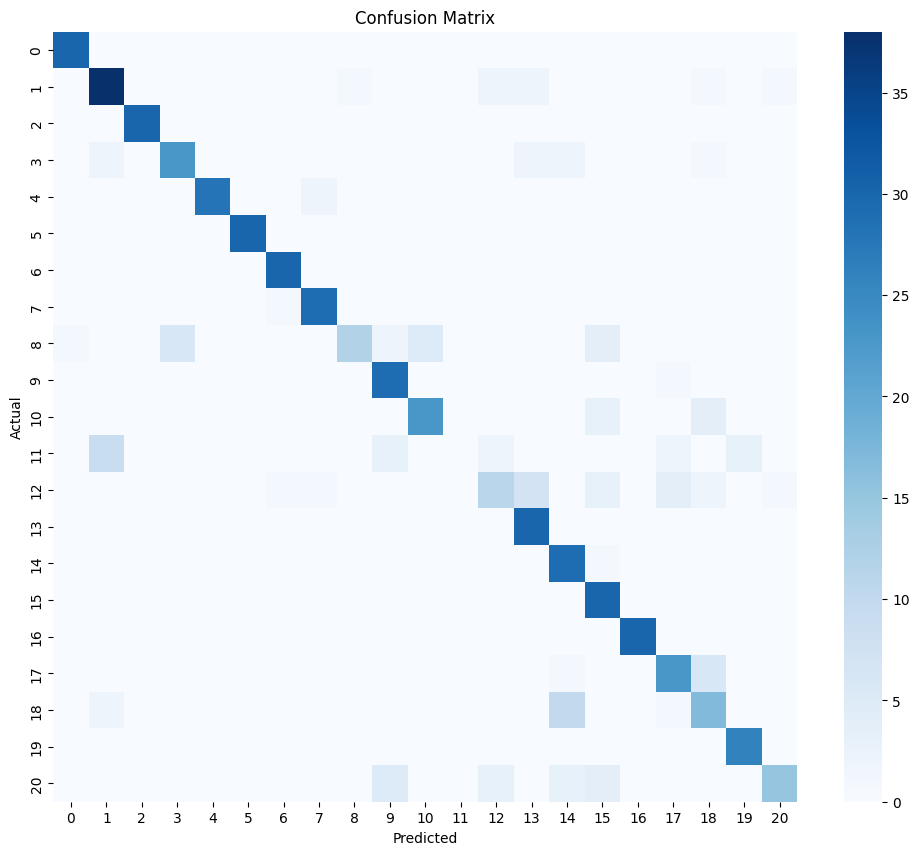

In [48]:
cm = confusion_matrix(all_labels,all_preds)

plt.figure(figsize=(12,10))

sns.heatmap(cm,cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

**Model Comparison Plot**

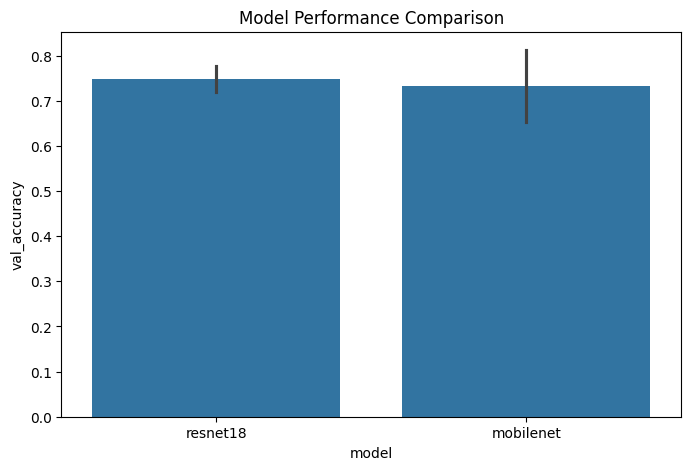

In [49]:
plt.figure(figsize=(8,5))

sns.barplot(data=results_df,x="model",y="val_accuracy")

plt.title("Model Performance Comparison")

plt.show()

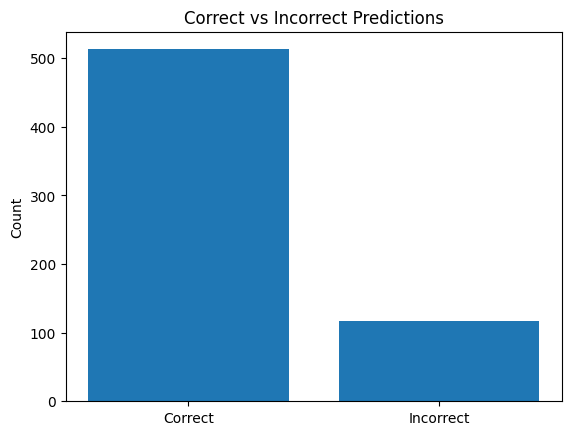

In [50]:
correct = 0
incorrect = 0

best_model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = best_model(images)
        _, preds = torch.max(outputs,1)

        correct += (preds == labels).sum().item()
        incorrect += (preds != labels).sum().item()

plt.figure()
plt.bar(["Correct","Incorrect"], [correct, incorrect])

plt.title("Correct vs Incorrect Predictions")
plt.ylabel("Count")

plt.show()

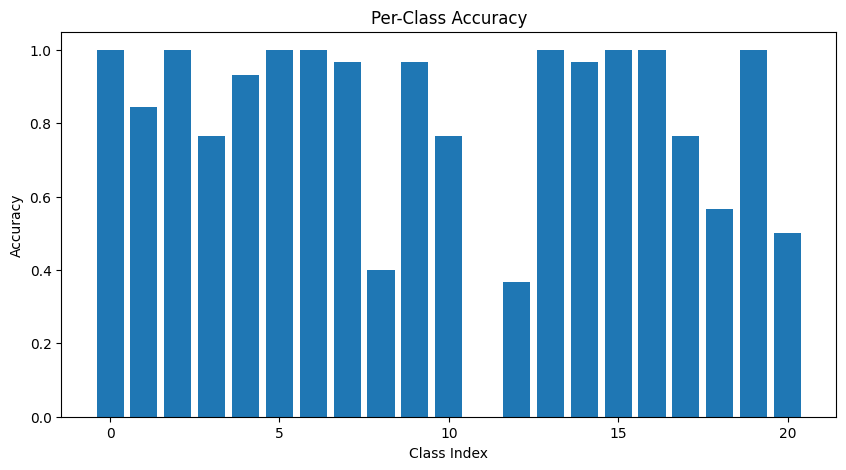

In [51]:
class_correct = [0] * num_classes
class_total = [0] * num_classes

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = best_model(images)
        _, preds = torch.max(outputs,1)

        for i in range(len(labels)):
            class_total[labels[i]] += 1
            if preds[i] == labels[i]:
                class_correct[labels[i]] += 1

class_acc = [c/t if t != 0 else 0 for c,t in zip(class_correct, class_total)]

plt.figure(figsize=(10,5))
plt.bar(range(num_classes), class_acc)

plt.title("Per-Class Accuracy")
plt.xlabel("Class Index")
plt.ylabel("Accuracy")

plt.show()

c:\Users\khowl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\khowl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\khowl\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

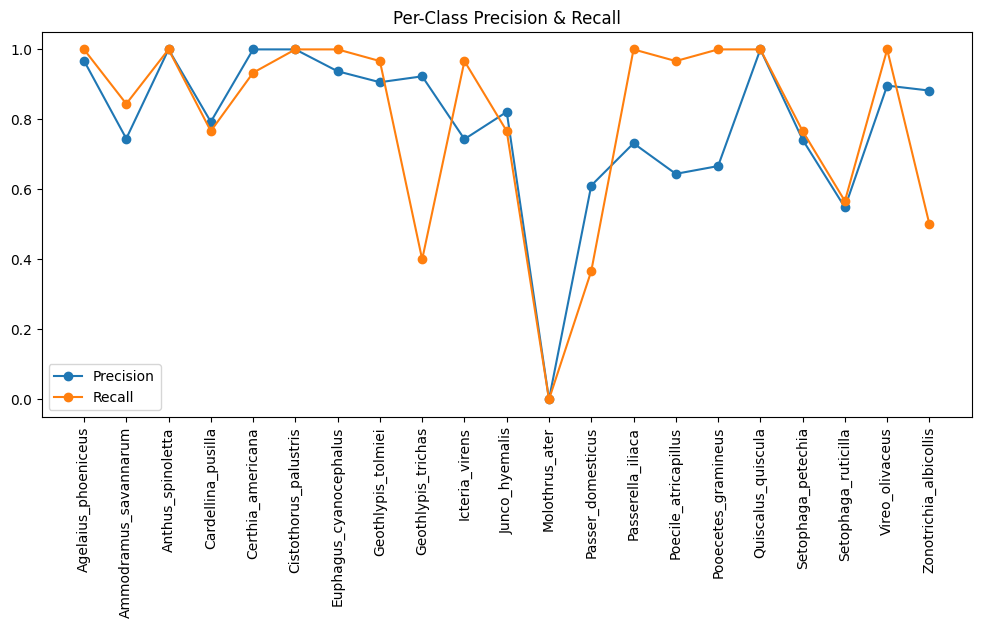

In [52]:
report = classification_report(all_labels, all_preds, target_names=classes, output_dict=True)

precision = [report[c]["precision"] for c in classes]
recall = [report[c]["recall"] for c in classes]

x = np.arange(len(classes))

plt.figure(figsize=(12,5))
plt.plot(x, precision, label="Precision", marker='o')
plt.plot(x, recall, label="Recall", marker='o')

plt.xticks(x, classes, rotation=90)
plt.legend()

plt.title("Per-Class Precision & Recall")

plt.show()

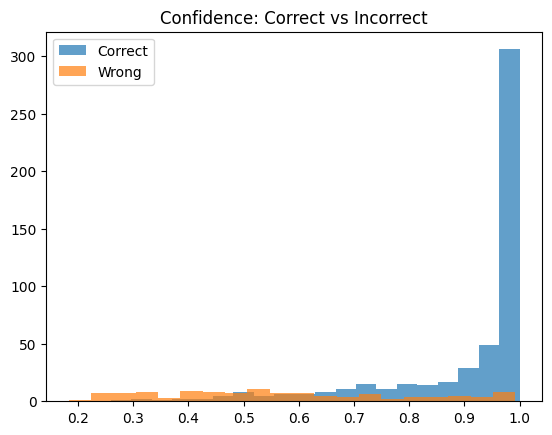

In [53]:
import torch.nn.functional as F

correct_conf = []
wrong_conf = []

best_model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = best_model(images)
        probs = F.softmax(outputs, dim=1)

        max_probs, preds = torch.max(probs, dim=1)

        for i in range(len(labels)):
            if preds[i] == labels[i]:
                correct_conf.append(max_probs[i].item())
            else:
                wrong_conf.append(max_probs[i].item())

plt.figure()
plt.hist(correct_conf, bins=20, alpha=0.7, label="Correct")
plt.hist(wrong_conf, bins=20, alpha=0.7, label="Wrong")

plt.legend()
plt.title("Confidence: Correct vs Incorrect")

plt.show()

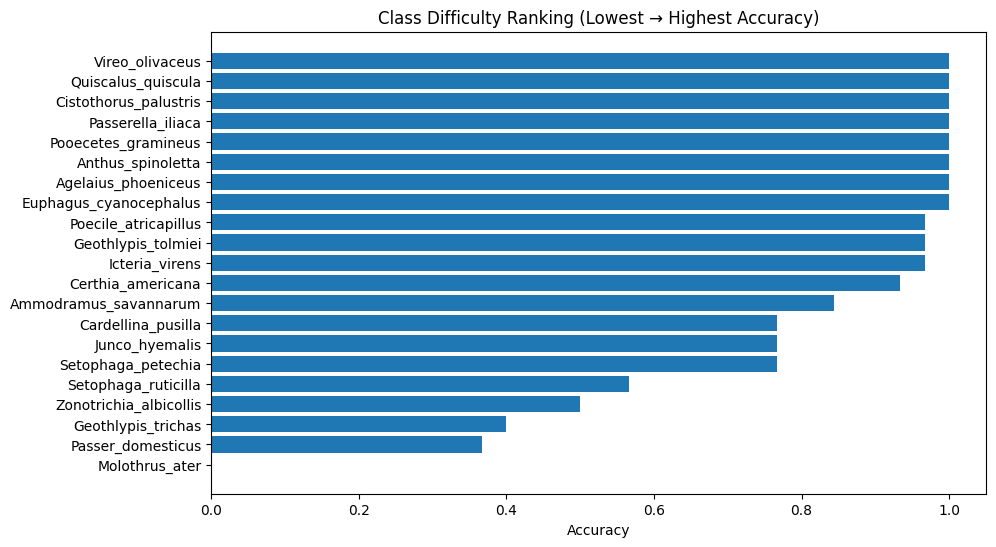

In [54]:
class_accuracy = cm.diagonal() / cm.sum(axis=1)

sorted_idx = np.argsort(class_accuracy)

sorted_classes = [classes[i] for i in sorted_idx]
sorted_acc = class_accuracy[sorted_idx]

plt.figure(figsize=(10,6))
plt.barh(sorted_classes, sorted_acc)

plt.title("Class Difficulty Ranking (Lowest → Highest Accuracy)")
plt.xlabel("Accuracy")

plt.show()

Grad-CAM + Top-K Predictions...

Image 1
True: Passerella_iliaca
Top 1: Passerella_iliaca (0.9194)
Top 2: Zonotrichia_albicollis (0.0762)
Top 3: Ammodramus_savannarum (0.0013)


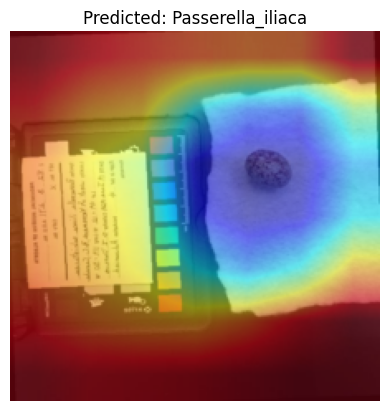


Image 2
True: Passerella_iliaca
Top 1: Passerella_iliaca (0.9964)
Top 2: Setophaga_petechia (0.0016)
Top 3: Ammodramus_savannarum (0.0005)


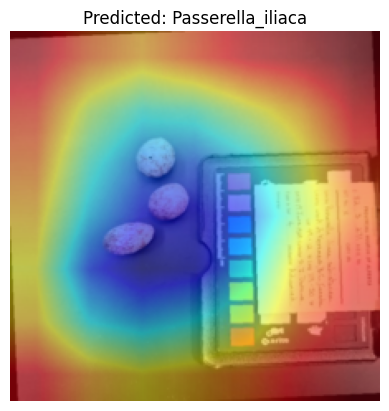


Image 3
True: Passerella_iliaca
Top 1: Passerella_iliaca (0.9686)
Top 2: Zonotrichia_albicollis (0.0159)
Top 3: Ammodramus_savannarum (0.0057)


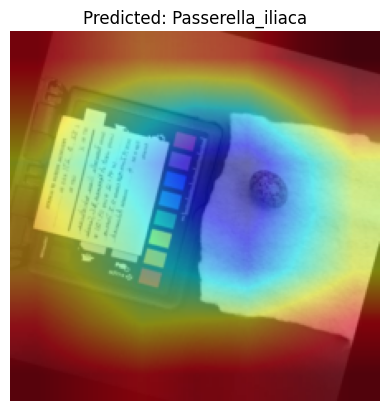

Misclassified samples with explanations...


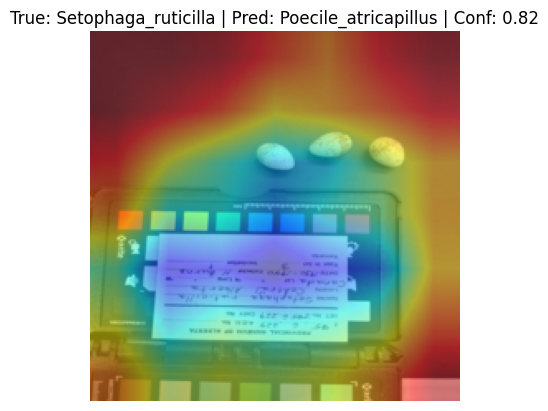

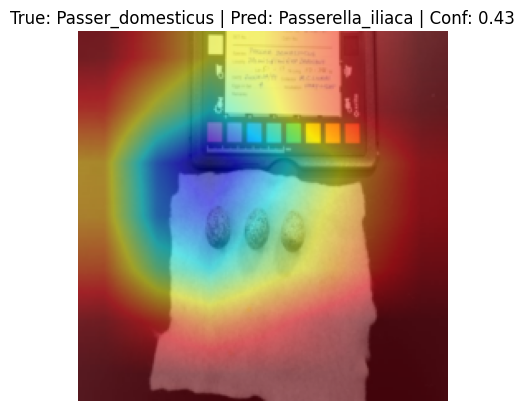

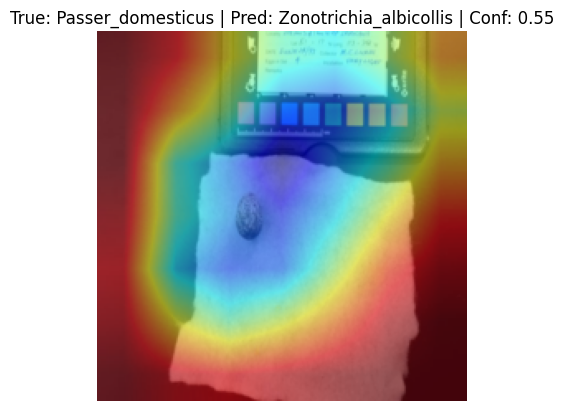

Confidence analysis...


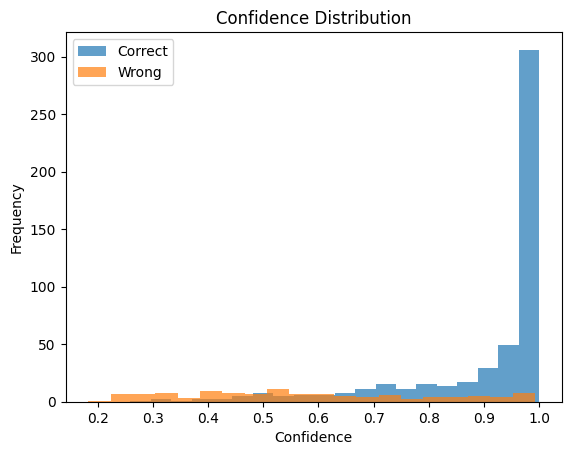

Most confused class pairs...
Setophaga_ruticilla → Poecile_atricapillus: 10 times
Molothrus_ater → Ammodramus_savannarum: 9 times
Passer_domesticus → Passerella_iliaca: 7 times
Setophaga_petechia → Setophaga_ruticilla: 6 times
Geothlypis_trichas → Cardellina_pusilla: 6 times
Confidence vs Accuracy...


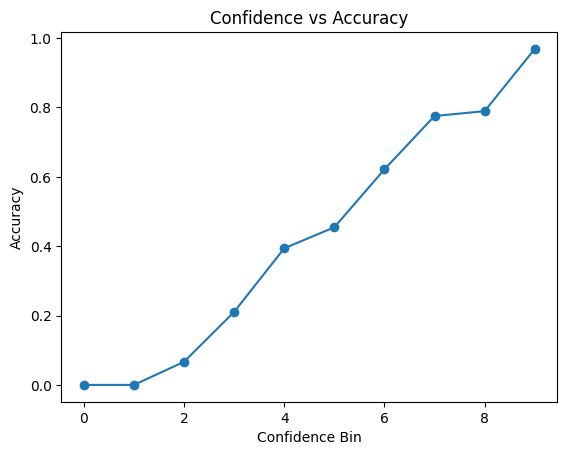

In [57]:
# =========================================================
# Explainability Section (Advanced)
# =========================================================

import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from sklearn.metrics import confusion_matrix


# =========================================================
# 1. Grad-CAM Setup
# =========================================================

if best_model_name == "resnet18":
    target_layers = [best_model.layer4[-1]]
elif best_model_name == "mobilenet":
    target_layers = [best_model.features[-1]]

cam = GradCAM(model=best_model, target_layers=target_layers)


# =========================================================
# 2. Grad-CAM + Top-K Predictions (Model Thinking)
# =========================================================

print("Grad-CAM + Top-K Predictions...")

test_imgs, test_labels = next(iter(test_loader))
test_imgs = test_imgs.to(device)

k = 3  # top predictions

for i in range(3):
    img = test_imgs[i].cpu()
    img_tensor = test_imgs[i].unsqueeze(0).to(device)

    outputs = best_model(img_tensor)
    probs = F.softmax(outputs, dim=1)

    top_probs, top_classes = torch.topk(probs, k)
    pred_class = top_classes[0][0]

    # Print decision reasoning
    print(f"\nImage {i+1}")
    print(f"True: {classes[test_labels[i]]}")
    for j in range(k):
        print(f"Top {j+1}: {classes[top_classes[0][j]]} ({top_probs[0][j].item():.4f})")

    # Grad-CAM
    grayscale_cam = cam(
        input_tensor=img_tensor,
        targets=[ClassifierOutputTarget(pred_class.item())]
    )

    img_np = img.permute(1, 2, 0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    visualization = show_cam_on_image(img_np, grayscale_cam[0])

    plt.imshow(visualization)
    plt.title(f"Predicted: {classes[pred_class.item()]}")
    plt.axis("off")
    plt.show()


# =========================================================
# 3. Grad-CAM for Misclassified Images
# =========================================================

print("Misclassified samples with explanations...")

misclassified_idx = [
    i for i, (p, t) in enumerate(zip(all_preds, all_labels)) if p != t
]

for idx in misclassified_idx[:3]:
    img, label = test_dataset[idx]
    img_tensor = img.unsqueeze(0).to(device)

    output = best_model(img_tensor)
    probs = F.softmax(output, dim=1)
    _, pred = torch.max(output, 1)

    grayscale_cam = cam(
        input_tensor=img_tensor,
        targets=[ClassifierOutputTarget(pred.item())]
    )

    img_np = img.permute(1, 2, 0).numpy()
    img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())

    visualization = show_cam_on_image(img_np, grayscale_cam[0])

    plt.imshow(visualization)
    plt.title(
        f"True: {classes[label]} | Pred: {classes[pred.item()]} | Conf: {probs[0][pred].item():.2f}"
    )
    plt.axis("off")
    plt.show()


# =========================================================
# 4. Confidence Distribution
# =========================================================

print("Confidence analysis...")

correct_conf = []
wrong_conf = []

best_model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = best_model(images)
        probs = F.softmax(outputs, dim=1)

        max_probs, preds = torch.max(probs, dim=1)

        for i in range(len(labels)):
            if preds[i] == labels[i]:
                correct_conf.append(max_probs[i].item())
            else:
                wrong_conf.append(max_probs[i].item())

plt.figure()
plt.hist(correct_conf, bins=20, alpha=0.7, label="Correct")
plt.hist(wrong_conf, bins=20, alpha=0.7, label="Wrong")

plt.legend()
plt.title("Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()


# =========================================================
# 5. Most Confused Classes (Decision Weakness)
# =========================================================

print("Most confused class pairs...")

cm = confusion_matrix(all_labels, all_preds)

confusions = []

for i in range(len(classes)):
    for j in range(len(classes)):
        if i != j and cm[i][j] > 0:
            confusions.append((cm[i][j], classes[i], classes[j]))

confusions = sorted(confusions, reverse=True)

for count, true_cls, pred_cls in confusions[:5]:
    print(f"{true_cls} → {pred_cls}: {count} times")


# =========================================================
# 6. Confidence Calibration (Trustworthiness)
# =========================================================

print("Confidence vs Accuracy...")

confidence_bins = [0]*10
accuracy_bins = [0]*10

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = best_model(images)
        probs = F.softmax(outputs, dim=1)

        max_probs, preds = torch.max(probs, dim=1)

        for i in range(len(labels)):
            bin_idx = int(max_probs[i].item() * 10)
            if bin_idx == 10:
                bin_idx = 9

            confidence_bins[bin_idx] += 1
            if preds[i] == labels[i]:
                accuracy_bins[bin_idx] += 1

acc_per_bin = [
    accuracy_bins[i] / confidence_bins[i] if confidence_bins[i] != 0 else 0
    for i in range(10)
]

plt.figure()
plt.plot(range(10), acc_per_bin, marker='o')
plt.title("Confidence vs Accuracy")
plt.xlabel("Confidence Bin")
plt.ylabel("Accuracy")
plt.show()